In [1]:
#imports needed for the notebook
from config import DATA_DIR
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob, os
from matplotlib.animation import FuncAnimation
from matplotlib import rcParams
from pathlib import Path
from IPython.display import HTML
import plotly.graph_objects as go
from itertools import product
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [2]:
#dictionary with the sizes, note: our convention is z,y,x thats why the smallest number is first here different to the paper
SIZES = {
    "archi1": (6, 20, 20),
    "archi2": (10, 30, 30),
    "archi3": (26, 40, 40),  
}


In [3]:
#method cuts out the cube, returns ...
def cut_cube(vol, z, y, x, size_zyx, pad_value=-1000): #values over the edge are padded with -1000, not sure if this even really happens
    dz, dy, dx = size_zyx
    z0, y0, x0 = z - dz // 2, y - dy // 2, x - dx // 2 #lower corner
    z1, y1, x1 = z0 + dz, y0 + dy, x0 + dx #upper corner

    cube = np.full(size_zyx, pad_value, dtype=vol.dtype) #pads the cube full with -1000

    sz0, sy0, sx0 = max(z0, 0), max(y0, 0), max(x0, 0)
    sz1, sy1, sx1 = min(z1, vol.shape[0]), min(y1, vol.shape[1]), min(x1, vol.shape[2])

    dz0, dy0, dx0 = sz0 - z0, sy0 - y0, sx0 - x0


    cube[dz0:dz0 + (sz1 - sz0),
         dy0:dy0 + (sy1 - sy0),
         dx0:dx0 + (sx1 - sx0)] = vol[sz0:sz1, sy0:sy1, sx0:sx1] #if the cube hangs partly outside the volume shape the data still gets written in correctly
    return cube

#this method clips the HU units from -1000 to 400 as it is done in the paper. Then it normalizes it to values between 0 and 1
#TODO??? quote from paper: The mean gray-scale value was subtracted to adjust the distribution of training and testing data.
def normalize(cube):
    cube = np.clip(cube, -1000, 400).astype(np.float32)
    return (cube + 1000.0) / 1400.0

# method to cut and normalize, input is the volume of data and z,y,x of nodule candidate, output is dictionary of all 3 archi cubes with names
def cut_all(vol, z, y, x):
    return {name: normalize(cut_cube(vol, z, y, x, size)) for name, size in SIZES.items()}

1


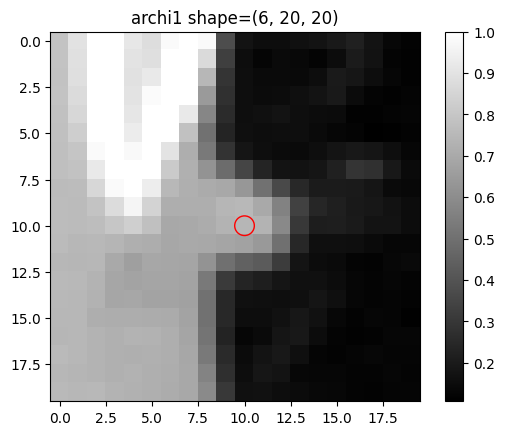

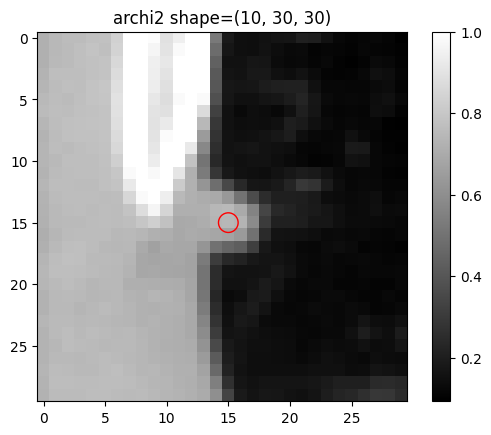

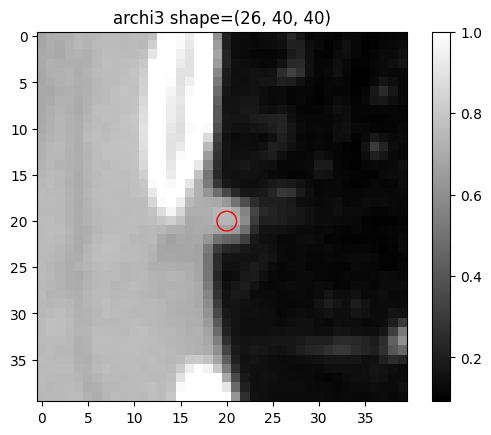

In [4]:
#this cell is just to check and visualize the boxes


path = Path(DATA_DIR) / "masked_scans0" / "1.3.6.1.4.1.14519.5.2.1.6279.6001.241570579760883349458693655367.npz"
data = np.load(path)
vol = data["volume"]
seriesuid = path.stem
idx = pd.read_csv(path.parent / "candidates_index.csv")

pos = idx[(idx["seriesuid"] == seriesuid) & (idx["class"] == 1)]
print(len(pos))
r = pos.iloc[0]
z, y, x = int(r["voxel_z"]), int(r["voxel_y"]), int(r["voxel_x"])

cubes = cut_all(vol, z, y, x)


for name, cube in cubes.items():
    mid = cube.shape[0] // 2
    plt.imshow(cube[mid], cmap="gray")
    plt.colorbar()
    plt.scatter([cube.shape[2] // 2], [cube.shape[1] // 2], s=200, facecolors="none", edgecolors="red")
    plt.title(f"{name} shape={cube.shape}")
    plt.show()

In [5]:
#loader
class LunaDataset(Dataset):
    def __init__(self, subset_dir, neg_ratio=1, seed=0):
        self.subset_dir = Path(subset_dir)
        idx = pd.read_csv(self.subset_dir / "candidates_index.csv")
        self.pos = idx[idx["class"] == 1].reset_index(drop=True)
        self.neg = idx[idx["class"] == 0].reset_index(drop=True)
        self.neg_ratio = neg_ratio
        self.rng = np.random.default_rng(seed)
        self.translations = list(product((-1, 0, 1), repeat=3))   # 27
        self.rotations = [0, 1, 2, 3]                             # 4
        self._cache_uid = None
        self._cache_vol = None
        self.build_samples()

    def build_samples(self):
        # each sample: (label, row_index, dz, dy, dx, k_rot)
        groups = {}   # seriesuid -> list of samples, for cache-friendly ordering

        for i in range(len(self.pos)):
            uid = self.pos.iloc[i]["seriesuid"]
            groups.setdefault(uid, [])
            for dz, dy, dx in self.translations:
                for k in self.rotations:
                    groups[uid].append((1, i, dz, dy, dx, k))

        n_neg = len(self.pos) * len(self.translations) * len(self.rotations) * self.neg_ratio
        neg_choice = self.rng.choice(len(self.neg), size=n_neg, replace=False)
        for j in neg_choice:
            uid = self.neg.iloc[j]["seriesuid"]
            groups.setdefault(uid, [])
            groups[uid].append((0, j, 0, 0, 0, 0))

        # shuffle scan order and within-scan order, keep each scan's samples contiguous
        uids = list(groups.keys())
        self.rng.shuffle(uids)
        self.samples = []
        for uid in uids:
            block = groups[uid]
            self.rng.shuffle(block)
            self.samples.extend(block)

    def _get_volume(self, uid):
        if uid != self._cache_uid:
            data = np.load(self.subset_dir / f"{uid}.npz")
            self._cache_vol = data["volume"]
            self._cache_uid = uid
        return self._cache_vol

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        label, row_i, dz, dy, dx, k = self.samples[i]
        row = self.pos.iloc[row_i] if label == 1 else self.neg.iloc[row_i]
        uid = row["seriesuid"]
        vol = self._get_volume(uid)

        z = int(row["voxel_z"]) + dz
        y = int(row["voxel_y"]) + dy
        x = int(row["voxel_x"]) + dx

        cubes = {}
        for name, size in SIZES.items():
            cube = cut_cube(vol, z, y, x, size)
            cube = np.rot90(cube, k, axes=(1, 2))      # rotate in transverse (y,x) plane
            cube = normalize(cube)                     # clip, scale to 0..1
            cubes[name] = torch.from_numpy(cube[None]) # add channel axis -> (1, Z, Y, X)

        return cubes, torch.tensor(label, dtype=torch.float32)

In [6]:
ds = LunaDataset(Path(DATA_DIR) / "masked_scans2", neg_ratio=1)
loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)

cubes, labels = next(iter(loader))
for name, c in cubes.items():
    print(name, c.shape)        # (32, 1, Z, Y, X)
print("labels", labels.shape, "positives in batch:", int(labels.sum()))
print("dataset size:", len(ds))

archi1 torch.Size([32, 1, 6, 20, 20])
archi2 torch.Size([32, 1, 10, 30, 30])
archi3 torch.Size([32, 1, 26, 40, 40])
labels torch.Size([32]) positives in batch: 11
dataset size: 39096


In [7]:
def compute_means(dataset, n_augmentations = 108):
    """Mean voxel value per architecture over the dataset's current epoch
    composition (positives + drawn negatives), matching the paper's
    full-training-set centering. Augmentation is simplified: translation by +-1 doesnt change a cubes sum by much"""
    
    sums = {name: 0.0 for name in SIZES}
    counts = {name: 0 for name in SIZES}


    seen = set()
    for label, row_i, *_ in dataset.samples:
        src = dataset.pos if label == 1 else dataset.neg
        key = (label, row_i)
        if key in seen:
            continue
        seen.add(key)

        row = src.iloc[row_i]
        vol = dataset._get_volume(row["seriesuid"])
        z, y, x = int(row["voxel_z"]), int(row["voxel_y"]), int(row["voxel_x"])
        for name, size in SIZES.items():
            cube = normalize(cut_cube(vol, z, y, x, size))
            if label == 1:
                sums[name] += cube.sum() * n_augmentations
                counts[name] += cube.size * n_augmentations
            else:
                sums[name] += cube.sum()
                counts[name] += cube.size


    return {name: sums[name] / counts[name] for name in SIZES}

In [8]:
ds = LunaDataset(Path(DATA_DIR) / "masked_scans2", neg_ratio=1)
MEANS = compute_means(ds)
print(MEANS)

{'archi1': 0.27557169366367484, 'archi2': 0.26433656115638493, 'archi3': 0.27453850920321826}


### First Training

In [52]:
# Only Archi-2
SIZES = {"archi2": (10, 30, 30)}

In [53]:
# Build the dataset on subset2 with 1:1 negatives.
ds = LunaDataset(Path(DATA_DIR) / "masked_scans2", neg_ratio=1)
print("dataset size:", len(ds))

dataset size: 39096


In [54]:
MEANS = compute_means(ds)
MEAN_A2 = MEANS["archi2"]
print("archi2 mean:", MEAN_A2)

archi2 mean: 0.26433656115638493


In [55]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [56]:
class Archi2(nn.Module):
    #No padding: 10,30,30 -> C1 8,26,26 -> M1 8,13,13 -> C2 6,9,9 -> C3 4,5,5.
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv3d(1, 64, kernel_size=(3, 5, 5))
        self.m1 = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))
        self.c2 = nn.Conv3d(64, 64, kernel_size=(3, 5, 5))
        self.c3 = nn.Conv3d(64, 64, kernel_size=(3, 5, 5))
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(0.2)
        self.fc1 = nn.Linear(64 * 4 * 5 * 5, 250)
        self.fc2 = nn.Linear(250, 2)
    #creates the one forward pass as in the paper
    def forward(self, v):
        v = self.relu(self.c1(v)) #first 1 convolutional layer, then relu
        v = self.m1(v) # just maxpooling
        v = self.drop(self.relu(self.c2(v))) #second conv layer, then relu, the drop randomly 20% of all outputs to generalize better
        v = self.drop(self.relu(self.c3(v))) #again
        v = v.flatten(1) #convert to 1d array
        v = self.drop(self.relu(self.fc1(v))) #6400 to 250 dense layer, then relu then drop again
        return self.fc2(v)            # logits for 2 classes; softmax via CrossEntropyLoss

In [ ]:
#initialize the weights as said in the paper 
def init_weights(m):
    if isinstance(m, (nn.Conv3d, nn.Linear)):
        nn.init.normal_(m.weight, mean=0.0, std=0.01)
        nn.init.zeros_(m.bias)

model = Archi2().to(device)
#model.apply(init_weights) #if this line is dropped pytorch standard init weights apply, could be better cause more modern
print(sum(p.numel() for p in model.parameters()), "parameters")

2220144 parameters


In [ ]:
# Paper hyperparameters
LR = 0.1  #is 0.3 in the paper but then it just doesnt learn at all
MOMENTUM = 0.9
BATCH = 200
DECAY_EVERY = 5000
DECAY_GAMMA = 0.95
EPOCHS = 10                          # adjust; paper trained to convergence

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)
# decay 5% every 5000 iterations -> step the scheduler once per 5000 optimizer steps
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=DECAY_EVERY, gamma=DECAY_GAMMA)

# num_workers=0 because LunaDataset caches one volume in the instance; workers would 
# duplicate that cache per process and break the scan-grouped single-slot assumption.
loader = DataLoader(ds, batch_size=BATCH, shuffle=False, num_workers=0)

In [62]:
def prep(cubes, labels):
    # cubes is a dict; with archi2-only SIZES it has one key
    x = cubes["archi2"].to(device)        # (B,1,Z,Y,X), already (0,1) scaled by loader
    x = x - MEAN_A2                        # subtract global mean
    y = labels.to(device).long()          # CrossEntropyLoss wants int class indices
    return x, y

In [63]:
from tqdm.notebook import tqdm

iteration = 0
for epoch in range(EPOCHS):
    ds.build_samples()
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f"epoch {epoch}", leave=True)
    for cubes, labels in pbar:
        x, y = prep(cubes, labels)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        scheduler.step()
        iteration += 1

        running_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

        pbar.set_postfix(loss=f"{running_loss/total:.4f}",
                         acc=f"{correct/total:.4f}",
                         lr=f"{scheduler.get_last_lr()[0]:.4f}")

    print(f"epoch {epoch:2d}  loss {running_loss/total:.4f}  "
          f"acc {correct/total:.4f}  iters {iteration}")

epoch 0:   0%|          | 0/196 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [64]:
# Probability for the positive class on a batch, for later FROC work.
model.eval()
with torch.no_grad():
    cubes, labels = next(iter(loader))
    x, y = prep(cubes, labels)
    probs = torch.softmax(model(x), dim=1)[:, 1]
print("sample positive-class probs:", probs[:10].cpu().numpy())

sample positive-class probs: [0.59590006 0.5959677  0.59591824 0.5958978  0.5957303  0.5957538
 0.5960053  0.5957416  0.59570956 0.5957913 ]


In [33]:
print(x.std().item())
print((x[0]-x[1]).abs().max().item())
print(x[:3].std().item(), model(x)[:3])

0.24360251426696777
0.6985714435577393
0.17581668496131897 tensor([[ 0.6785, -0.7288],
        [ 0.6785, -0.7288],
        [ 0.6785, -0.7288]], grad_fn=<SliceBackward0>)


## Evaluation

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import pandas as pd


class EvalDataset(Dataset):
    """Scores every candidate exactly once: no augmentation, no negative
    subsampling. One cube per candidate at its center, archi2 only.
    Reuses the module-level SIZES, cut_cube, normalize from the loader."""
    def __init__(self, subset_dir):
        self.subset_dir = Path(subset_dir)
        idx = pd.read_csv(self.subset_dir / "candidates_index.csv")
        # keep every candidate, both classes, in original order
        self.rows = idx.reset_index(drop=True)
        self._cache_uid = None
        self._cache_vol = None

    def _get_volume(self, uid):
        if uid != self._cache_uid:
            data = np.load(self.subset_dir / f"{uid}.npz")
            self._cache_vol = data["volume"]
            self._cache_uid = uid
        return self._cache_vol

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        row = self.rows.iloc[i]
        vol = self._get_volume(row["seriesuid"])
        z, y, x = int(row["voxel_z"]), int(row["voxel_y"]), int(row["voxel_x"])
        cube = normalize(cut_cube(vol, z, y, x, SIZES["archi2"]))   # no rotation, no shift
        cube = torch.from_numpy(cube[None])                          # (1,Z,Y,X)
        return cube, torch.tensor(int(row["class"]), dtype=torch.float32)


def evaluate_froc(model, subset_dir, n_scans=None, batch_size=256):
    """Candidate-level approximate FROC on a subset.

    NOT the official LUNA16 CPM: scores are per-candidate (each candidate's
    own label vs predicted prob), with no radius-based matching against the
    nodule annotations and no bootstrap CIs. Use it as a development proxy,
    not a paper-comparable number.

    Returns (cpm_proxy, dict of sensitivity at each FP/scan operating point)."""
    eval_ds = EvalDataset(subset_dir)
    if n_scans is None:
        n_scans = eval_ds.rows["seriesuid"].nunique()

    loader = DataLoader(eval_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    device = next(model.parameters()).device

    all_probs = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for cubes, labels in loader:
            x = cubes.to(device) - MEAN_A2
            p = torch.softmax(model(x), dim=1)[:, 1]     # P(nodule)
            all_probs.append(p.cpu().numpy())
            all_labels.append(labels.numpy())

    probs = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)

    # sweep threshold high -> low, accumulate true and false positives
    order = np.argsort(-probs)
    l_sorted = labels[order]
    tp = np.cumsum(l_sorted == 1)
    fp = np.cumsum(l_sorted == 0)
    total_pos = int((labels == 1).sum())

    sens = tp / total_pos
    fp_per_scan = fp / n_scans

    points = [0.125, 0.25, 0.5, 1, 2, 4, 8]
    sens_at = np.interp(points, fp_per_scan, sens)   # interpolate onto the 7 LUNA16 rates
    cpm_proxy = float(sens_at.mean())

    sens_dict = {pt: float(s) for pt, s in zip(points, sens_at)}
    return cpm_proxy, sens_dict

In [ ]:
cpm, sens = evaluate_froc(model, Path(DATA_DIR) / "masked_scans1")
print(f"approx CPM (proxy): {cpm:.4f}")
for pt, s in sens.items():
    print(f"  {pt:>5} FP/scan -> sensitivity {s:.3f}")